<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/F_Hybrid_(BERT%2BRoBERTa)_Feature_Fusion_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Installations**

In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    BertModel,
    RobertaModel,
)

from torch.optim import AdamW

from datasets import Dataset

## **Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [ ]:
df = df[["Title", "Text", "Sentiment"]]

df = df.dropna(subset=["Title", "Text", "Sentiment"])

df = df.drop_duplicates()

df["Combined_Text"] = (
    df["Title"].astype(str).str.strip() + " " +
    df["Text"].astype(str).str.strip()
)


df = df[["Combined_Text", "Sentiment"]]

df.reset_index(drop=True, inplace=True)

df.head()

,Combined_Text,Sentiment
0,Wonderful Experience This was our third tea fa...,Positive
1,In-TEA-resting A worth visit for everyone who ...,Positive
2,"The best tea experience, great history Hidden ...",Positive
3,Informative tour We really enjoyed our tour at...,Positive
4,Under appreciated - well worth We spend a few ...,Positive


In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Sentiment"])

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


## **Train / Validation / Test Split**

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_df["label"]
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

5012
1075
1075


In [ ]:
train_dataset = Dataset.from_pandas(train_df[["Combined_Text","label"]])
val_dataset = Dataset.from_pandas(val_df[["Combined_Text","label"]])
test_dataset = Dataset.from_pandas(test_df[["Combined_Text","label"]])

## **Metric Function**

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


## **Hybrid Appraoch - Feature Fusion**

In [ ]:
BERT_MODEL = "bert-base-uncased"
ROBERTA_MODEL = "roberta-base"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
import torch
from torch.utils.data import Dataset

class HybridDataset(Dataset):

    def __init__(self, dataframe, bert_tokenizer, roberta_tokenizer, max_length=128):

        self.texts = dataframe["Combined_Text"].tolist()
        self.labels = dataframe["label"].tolist()

        self.bert_tokenizer = bert_tokenizer
        self.roberta_tokenizer = roberta_tokenizer

        self.max_length = max_length

        # for param in self.bert.parameters():
        #     param.requires_grad = False

        # for param in self.roberta.parameters():
        #     param.requires_grad = False


    def __len__(self):
        return len(self.texts)


    def __getitem__(self, idx):

        text = self.texts[idx]
        label = self.labels[idx]

        # -------- BERT --------
        bert_encoding = self.bert_tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # -------- RoBERTa --------
        roberta_encoding = self.roberta_tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "bert_input_ids": bert_encoding["input_ids"].squeeze(0),
            "bert_attention_mask": bert_encoding["attention_mask"].squeeze(0),

            "roberta_input_ids": roberta_encoding["input_ids"].squeeze(0),
            "roberta_attention_mask": roberta_encoding["attention_mask"].squeeze(0),

            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
dataset = HybridDataset(train_df, bert_tokenizer, roberta_tokenizer)

sample = dataset[0]

print(sample.keys())

dict_keys(['bert_input_ids', 'bert_attention_mask', 'roberta_input_ids', 'roberta_attention_mask', 'labels'])


In [ ]:
train_dataset_h = HybridDataset(train_df, bert_tokenizer, roberta_tokenizer)
val_dataset_h   = HybridDataset(val_df, bert_tokenizer, roberta_tokenizer)
test_dataset_h  = HybridDataset(test_df, bert_tokenizer, roberta_tokenizer)

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel, RobertaModel

class BertRobertaHybrid(nn.Module):

    def __init__(self, num_labels=3):

        super(BertRobertaHybrid, self).__init__()

        # Pretrained Models
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.roberta = RobertaModel.from_pretrained("roberta-base")

        # Feature Fusion Classifier
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(768 * 2, 768)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(768, 256)
        self.fc3 = nn.Linear(256, num_labels)

    def forward(
        self,
        bert_input_ids,
        bert_attention_mask,
        roberta_input_ids,
        roberta_attention_mask
    ):

        # ---------------- BERT ----------------

        bert_output = self.bert(
            input_ids=bert_input_ids,
            attention_mask=bert_attention_mask
        )

        bert_cls = bert_output.last_hidden_state[:, 0, :]

        # ---------------- RoBERTa ----------------

        roberta_output = self.roberta(
            input_ids=roberta_input_ids,
            attention_mask=roberta_attention_mask
        )

        roberta_cls = roberta_output.last_hidden_state[:, 0, :]

        # ---------------- FEATURE FUSION ----------------

        fused = torch.cat(
            (bert_cls, roberta_cls),
            dim=1
        )                      # Shape = (batch_size, 1536)

        # ---------------- CLASSIFIER ----------------

        x = self.dropout(fused)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc3(x)

        return logits

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset_h,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset_h,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset_h,
    batch_size=16,
    shuffle=False
)

In [ ]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(key, value.shape)

bert_input_ids torch.Size([16, 128])
bert_attention_mask torch.Size([16, 128])
roberta_input_ids torch.Size([16, 128])
roberta_attention_mask torch.Size([16, 128])
labels torch.Size([16])


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([2.0857, 1.1028, 0.6197])


In [ ]:
criterion = criterion = nn.CrossEntropyLoss()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertRobertaHybrid(num_labels=3)

model.to(device)

print(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def evaluate(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in dataloader:

            bert_input_ids = batch["bert_input_ids"].to(device)
            bert_attention_mask = batch["bert_attention_mask"].to(device)

            roberta_input_ids = batch["roberta_input_ids"].to(device)
            roberta_attention_mask = batch["roberta_attention_mask"].to(device)

            labels = batch["labels"].to(device)

            outputs = model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                roberta_input_ids=roberta_input_ids,
                roberta_attention_mask=roberta_attention_mask
            )

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="macro"
    )

    return (
        total_loss / len(dataloader),
        accuracy,
        precision,
        recall,
        f1
    )

In [ ]:
best_f1 = 0

epochs = 3

In [ ]:
for epoch in range(epochs):

    model.train()

    train_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        bert_input_ids = batch["bert_input_ids"].to(device)
        bert_attention_mask = batch["bert_attention_mask"].to(device)

        roberta_input_ids = batch["roberta_input_ids"].to(device)
        roberta_attention_mask = batch["roberta_attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            bert_input_ids=bert_input_ids,
            bert_attention_mask=bert_attention_mask,
            roberta_input_ids=roberta_input_ids,
            roberta_attention_mask=roberta_attention_mask
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss : {train_loss/len(train_loader):.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Validation Precision : {val_precision:.4f}")
    print(f"Validation Recall : {val_recall:.4f}")
    print(f"Validation Macro F1 : {val_f1:.4f}")

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "best_hybrid_model.pt"
        )

        print("Best model saved.")


Epoch 1/3
Train Loss : 0.7232
Validation Loss : 0.5146
Validation Accuracy : 0.7795
Validation Precision : 0.7312
Validation Recall : 0.7546
Validation Macro F1 : 0.7399
Best model saved.

Epoch 2/3
Train Loss : 0.4677
Validation Loss : 0.5007
Validation Accuracy : 0.7860
Validation Precision : 0.7437
Validation Recall : 0.7487
Validation Macro F1 : 0.7432
Best model saved.

Epoch 3/3
Train Loss : 0.3146
Validation Loss : 0.5929
Validation Accuracy : 0.7805
Validation Precision : 0.7784
Validation Recall : 0.7012
Validation Macro F1 : 0.7269


In [ ]:
model.load_state_dict(
    torch.load("best_hybrid_model.pt")
)

<All keys matched successfully>

In [ ]:
test_loss, test_acc, test_precision, test_recall, test_f1 = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n========== TEST RESULTS ==========")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall : {test_recall:.4f}")
print(f"Macro F1 : {test_f1:.4f}")


========== TEST RESULTS ==========
Accuracy : 0.7730
Precision : 0.7321
Recall : 0.7443
Macro F1 : 0.7335


In [ ]:
model.load_state_dict(torch.load("best_hybrid_model.pt"))

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        bert_input_ids = batch["bert_input_ids"].to(device)
        bert_attention_mask = batch["bert_attention_mask"].to(device)

        roberta_input_ids = batch["roberta_input_ids"].to(device)
        roberta_attention_mask = batch["roberta_attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            bert_input_ids=bert_input_ids,
            bert_attention_mask=bert_attention_mask,
            roberta_input_ids=roberta_input_ids,
            roberta_attention_mask=roberta_attention_mask
        )

        preds = torch.argmax(outputs, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    Negative       0.68      0.80      0.74       172
     Neutral       0.67      0.53      0.59       325
    Positive       0.85      0.90      0.87       578

    accuracy                           0.77      1075
   macro avg       0.73      0.74      0.73      1075
weighted avg       0.77      0.77      0.77      1075



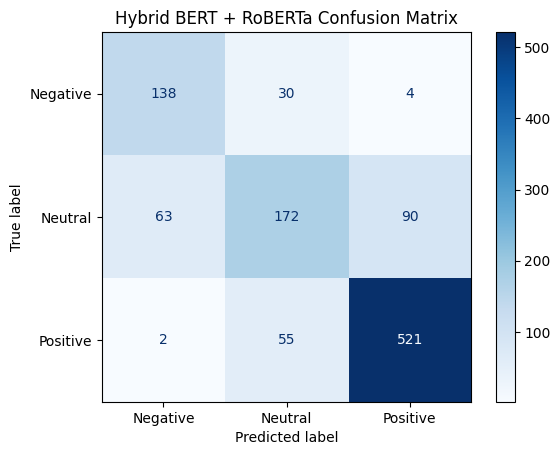

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Hybrid BERT + RoBERTa Confusion Matrix")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "/content/Hybrid_BERT_RoBERTa.pt"
)

In [ ]:
bert_tokenizer.save_pretrained("/content/BERT_Tokenizer")

roberta_tokenizer.save_pretrained("/content/RoBERTa_Tokenizer")

('/content/RoBERTa_Tokenizer/tokenizer_config.json',
 '/content/RoBERTa_Tokenizer/tokenizer.json')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json

input_file = "/content/drive/MyDrive/Colab Notebooks/F_Hybrid (BERT+RoBERTa)-Feature Fusion_1_3.ipynb"
output_file = "/content/drive/MyDrive/Colab Notebooks/F_Hybrid (BERT+RoBERTa)-Feature Fusion_1_3.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Clean notebook saved for GitHub:", output_file)

Clean notebook saved for GitHub: /content/drive/MyDrive/Colab Notebooks/F_Hybrid (BERT+RoBERTa)-Feature Fusion_1_3.ipynb
